# CS303 Machine Learning Lab
## Experiment 4
### (24/CS/232)

**Aim:**
To implement Linear Regression from scratch on the House price dataset



**1. Importing Permitted Libraries & Loading Dataset**

In [ ]:
# importing numerical, data manipulation, and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# loading the Housing dataset directly from the repository
url = "https://github.com/JyRaGa/CS303-Machine-Learning_Coursework/raw/refs/heads/main/datasets/Housing.csv"
df = pd.read_csv(url)

print("--- Dataset Dimensions ---")
print(f"Total Samples: {df.shape[0]}, Total Features: {df.shape[1]}")
print("\n--- First 5 Records ---")
display(df.head())

--- Dataset Dimensions ---
Total Samples: 545, Total Features: 13

--- First 5 Records ---


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


**2. Implementing Linear Regression & Evaluation Metrics from Scratch**

The entire mathematical lifecycle—train-test splitting, parameter estimation via the Normal Equation, and metric calculations—is defined purely using NumPy.

In [ ]:
# custom train-test split function
def train_test_split_scratch(X, y, test_size=0.30, random_state=42):
    np.random.seed(random_state)
    n_samples = len(X)
    indices = np.arange(n_samples)
    np.random.shuffle(indices)

    split_idx = int(n_samples * (1 - test_size))
    train_indices = indices[:split_idx]
    test_indices = indices[split_idx:]

    return X.iloc[train_indices], X.iloc[test_indices], y.iloc[train_indices], y.iloc[test_indices]

# custom linear regression class based on ordinary least squares
class LinearRegressionScratch:
    def __init__(self):
        self.coefficients = None  # feature slopes (beta_1 to beta_p)
        self.intercept = None     # bias term (beta_0)
        self.beta = None          # combined weight vector

    def fit(self, X, y):
        # convert pandas structures to numpy arrays
        X_mat = np.array(X, dtype=np.float64)
        y_vec = np.array(y, dtype=np.float64)

        # augment feature matrix with leading column of ones for intercept
        ones = np.ones((X_mat.shape[0], 1))
        X_aug = np.hstack((ones, X_mat))

        # solve Normal Equation: beta = (X^T * X)^(-1) * X^T * y
        # using pseudo-inverse (pinv) for numerical stability
        self.beta = np.linalg.pinv(X_aug.T @ X_aug) @ X_aug.T @ y_vec

        self.intercept = self.beta[0]
        self.coefficients = self.beta[1:]

    def predict(self, X):
        X_mat = np.array(X, dtype=np.float64)
        ones = np.ones((X_mat.shape[0], 1))
        X_aug = np.hstack((ones, X_mat))
        return X_aug @ self.beta

# custom evaluation metric functions
def mean_absolute_error_scratch(y_true, y_pred):
    return np.mean(np.abs(np.array(y_true) - np.array(y_pred)))

def mean_squared_error_scratch(y_true, y_pred):
    return np.mean((np.array(y_true) - np.array(y_pred)) ** 2)

def root_mean_squared_error_scratch(y_true, y_pred):
    return np.sqrt(mean_squared_error_scratch(y_true, y_pred))

def r2_score_scratch(y_true, y_pred):
    y_t = np.array(y_true)
    y_p = np.array(y_pred)
    ss_res = np.sum((y_t - y_p) ** 2)
    ss_tot = np.sum((y_t - np.mean(y_t)) ** 2)
    return 1.0 - (ss_res / ss_tot)

**3. Preprocessing & Correlation Heatmap**

Categorical variables are encoded into binary columns (`drop_first=True`) to prepare the continuous feature space.

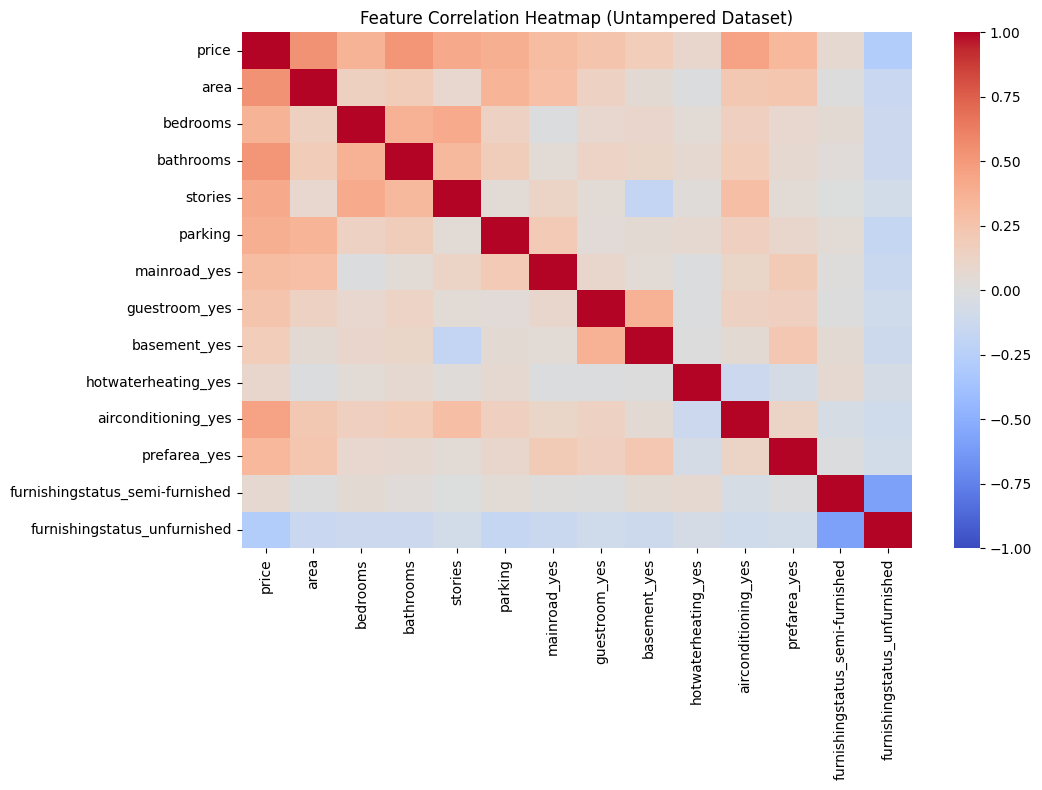

In [ ]:
# one-hot encoding categorical features
categorical_cols = df.select_dtypes(include='object').columns
df_processed = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=float)

# plotting the feature correlation heatmap
plt.figure(figsize=(11, 8))
sns.heatmap(df_processed.corr(), annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap (Untampered Dataset)')
plt.tight_layout()
plt.show()

**4. Phase 1: Baseline Model Training & Parameter Extraction**

The model is trained on the clean dataset. Intercept $\beta_0$ and all feature slopes $\beta_j$ are extracted and printed.

In [ ]:
# separating features (X) and target (y)
X = df_processed.drop('price', axis=1)
y = df_processed['price']

# performing 70:30 train-test split
X_train, X_test, y_train, y_test = train_test_split_scratch(X, y, test_size=0.30, random_state=42)

# fitting the normal model
model_normal = LinearRegressionScratch()
model_normal.fit(X_train, y_train)
y_pred_normal = model_normal.predict(X_test)

# computing baseline evaluation metrics
r2_normal = r2_score_scratch(y_test, y_pred_normal)
mae_normal = mean_absolute_error_scratch(y_test, y_pred_normal)
mse_normal = mean_squared_error_scratch(y_test, y_pred_normal)
rmse_normal = root_mean_squared_error_scratch(y_test, y_pred_normal)

# displaying fitted parameters
print("=" * 65)
print(f"NORMAL MODEL INTERCEPT (β₀): {model_normal.intercept:,.2f}")
print("=" * 65)
print("FEATURE SLOPES / COEFFICIENTS (βⱼ):")
for feature, coef in zip(X.columns, model_normal.coefficients):
    print(f"  • {feature:<35}: {coef:>15,.2f}")
print("=" * 65)
print(f"R-squared (R²) Score : {r2_normal:.4f}")
print(f"Mean Absolute Error (MAE): {mae_normal:,.2f}")
print(f"Mean Squared Error (MSE) : {mse_normal:,.2f}")
print(f"Root Mean Squared Error  : {rmse_normal:,.2f}")
print("=" * 65)

NORMAL MODEL INTERCEPT (β₀): -110,650.02
FEATURE SLOPES / COEFFICIENTS (βⱼ):
  • area                               :          225.54
  • bedrooms                           :       89,961.34
  • bathrooms                          :    1,022,333.14
  • stories                            :      514,840.31
  • parking                            :      241,967.73
  • mainroad_yes                       :      477,283.50
  • guestroom_yes                      :      191,771.74
  • basement_yes                       :      301,525.58
  • hotwaterheating_yes                :      966,940.40
  • airconditioning_yes                :      981,570.66
  • prefarea_yes                       :      807,637.85
  • furnishingstatus_semi-furnished    :       34,519.03
  • furnishingstatus_unfurnished       :     -316,170.17
R-squared (R²) Score : 0.6194
Mean Absolute Error (MAE): 815,292.31
Mean Squared Error (MSE) : 1,300,084,932,735.04
Root Mean Squared Error  : 1,140,212.67


**5. Baseline Visualizations: Actual vs. Predicted & Residual Distribution**

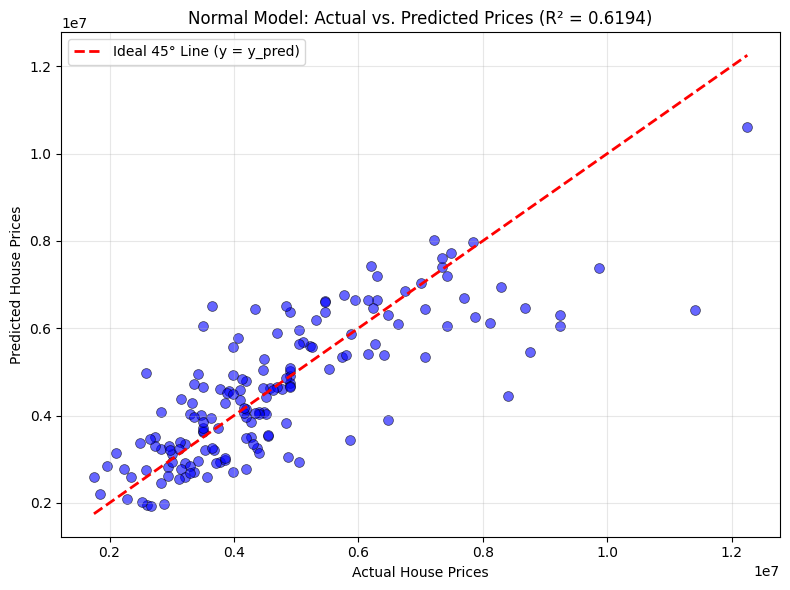

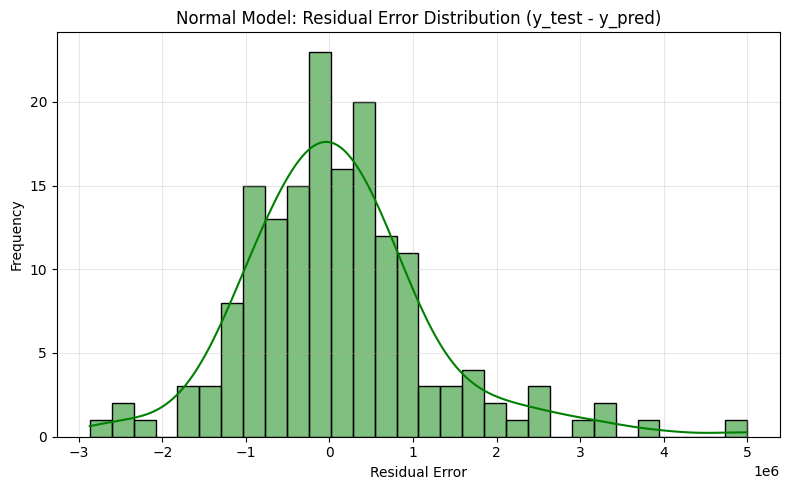

In [ ]:
# 1. Actual vs Predicted Scatter Plot with 45-degree reference line
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_normal, alpha=0.6, color='blue', edgecolor='black', s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2, label='Ideal 45° Line (y = y_pred)')
plt.xlabel('Actual House Prices')
plt.ylabel('Predicted House Prices')
plt.title(f'Normal Model: Actual vs. Predicted Prices (R² = {r2_normal:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Residual Error Distribution
residuals_normal = y_test - y_pred_normal
plt.figure(figsize=(8, 5))
sns.histplot(residuals_normal, kde=True, color='green', bins=30)
plt.title('Normal Model: Residual Error Distribution (y_test - y_pred)')
plt.xlabel('Residual Error')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**6. Phase 2: Injecting Extreme Artificial Outliers**

A set of 5 extreme outlier records is appended to evaluate the sensitivity of the closed-form solution. These records represent anomalous data (e.g., properties with minimal area but 50M+ price, and massive 16,000 sq ft properties priced near zero).

In [ ]:
# creating artificial outlier instances
outliers = pd.DataFrame({
    'price': [50000000, 45000000, 100000, 200000, 60000000],
    'area': [1000, 1500, 15000, 16000, 1200],
    'bedrooms': [1, 2, 6, 6, 1],
    'bathrooms': [1, 1, 4, 4, 1],
    'stories': [1, 1, 4, 4, 1],
    'mainroad': ['no', 'no', 'yes', 'yes', 'no'],
    'guestroom': ['no', 'no', 'yes', 'yes', 'no'],
    'basement': ['no', 'no', 'yes', 'yes', 'no'],
    'hotwaterheating': ['no', 'no', 'yes', 'yes', 'no'],
    'airconditioning': ['no', 'no', 'yes', 'yes', 'no'],
    'parking': [0, 0, 3, 3, 0],
    'prefarea': ['no', 'no', 'yes', 'yes', 'no'],
    'furnishingstatus': ['unfurnished', 'unfurnished', 'furnished', 'furnished', 'unfurnished']
})

# appending to the original dataset
df_outliers = pd.concat([df, outliers], ignore_index=True)
df_outliers_processed = pd.get_dummies(df_outliers, columns=categorical_cols, drop_first=True, dtype=float)

# ensuring matching feature columns
X_out = df_outliers_processed.drop('price', axis=1).reindex(columns=X.columns, fill_value=0.0)
y_out = df_outliers_processed['price']

# splitting the corrupted dataset
X_train_out, X_test_out, y_train_out, y_test_out = train_test_split_scratch(X_out, y_out, test_size=0.30, random_state=42)

# fitting the corrupted model from scratch
model_outlier = LinearRegressionScratch()
model_outlier.fit(X_train_out, y_train_out)
y_pred_outlier = model_outlier.predict(X_test_out)

# computing corrupted evaluation metrics
r2_outlier = r2_score_scratch(y_test_out, y_pred_outlier)
mae_outlier = mean_absolute_error_scratch(y_test_out, y_pred_outlier)
mse_outlier = mean_squared_error_scratch(y_test_out, y_pred_outlier)
rmse_outlier = root_mean_squared_error_scratch(y_test_out, y_pred_outlier)

# displaying corrupted model parameters
print("=" * 65)
print(f"OUTLIER-CORRUPTED MODEL INTERCEPT (β₀): {model_outlier.intercept:,.2f}")
print("=" * 65)
print("FEATURE SLOPES / COEFFICIENTS (βⱼ):")
for feature, coef in zip(X_out.columns, model_outlier.coefficients):
    print(f"  • {feature:<35}: {coef:>15,.2f}")
print("=" * 65)
print(f"R-squared (R²) Score : {r2_outlier:.4f}")
print(f"Mean Absolute Error (MAE): {mae_outlier:,.2f}")
print(f"Mean Squared Error (MSE) : {mse_outlier:,.2f}")
print(f"Root Mean Squared Error  : {rmse_outlier:,.2f}")
print("=" * 65)

OUTLIER-CORRUPTED MODEL INTERCEPT (β₀): 5,577,290.63
FEATURE SLOPES / COEFFICIENTS (βⱼ):
  • area                               :           72.05
  • bedrooms                           :     -983,692.52
  • bathrooms                          :    1,286,652.01
  • stories                            :      586,187.15
  • parking                            :      358,432.65
  • mainroad_yes                       :   -1,804,287.08
  • guestroom_yes                      :      322,198.87
  • basement_yes                       :      -56,422.34
  • hotwaterheating_yes                :    1,195,218.40
  • airconditioning_yes                :      872,817.50
  • prefarea_yes                       :    1,123,643.42
  • furnishingstatus_semi-furnished    :      -76,672.05
  • furnishingstatus_unfurnished       :      228,449.63
R-squared (R²) Score : -0.2005
Mean Absolute Error (MAE): 1,420,857.68
Mean Squared Error (MSE) : 4,382,175,851,206.32
Root Mean Squared Error  : 2,093,364.72


**7. Comparative Visualizations: Parameter Drift & Regression Skew**

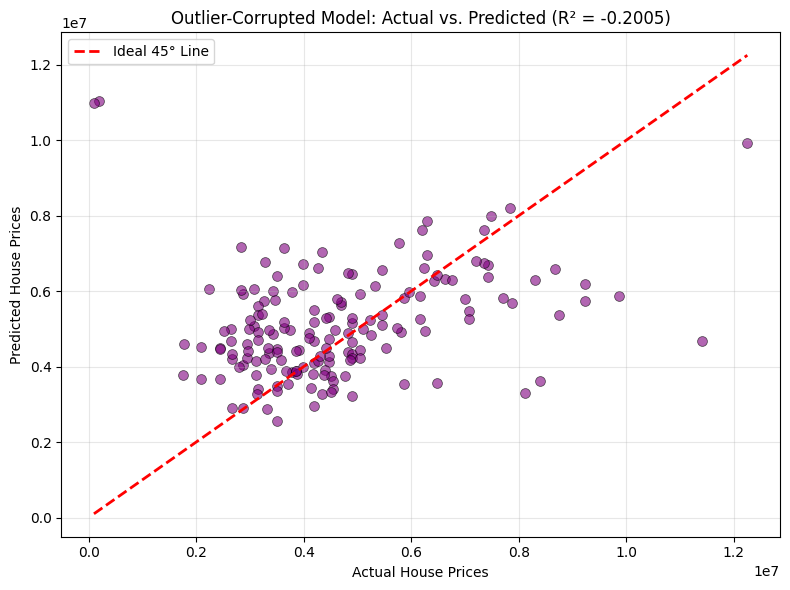

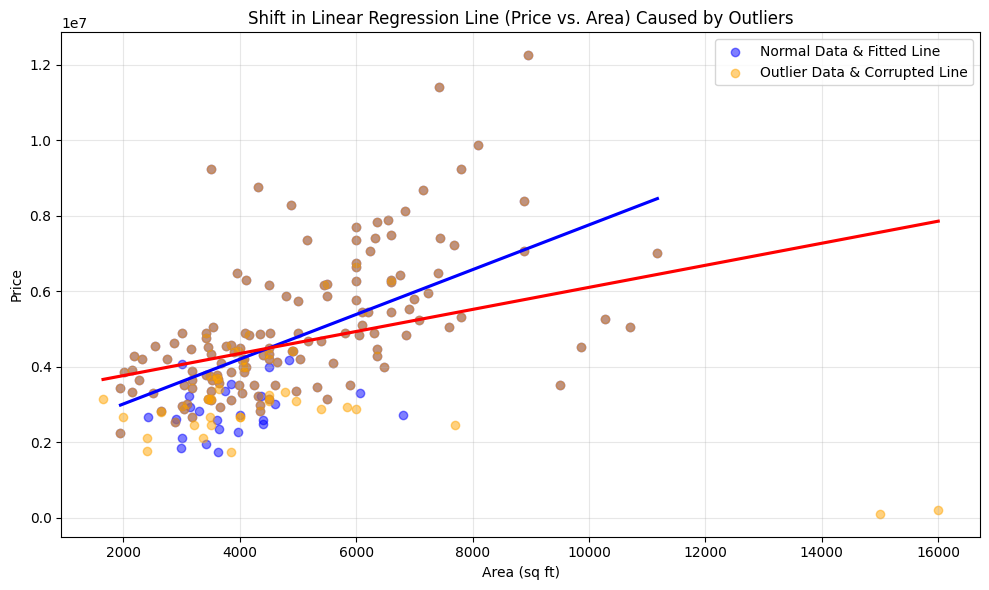

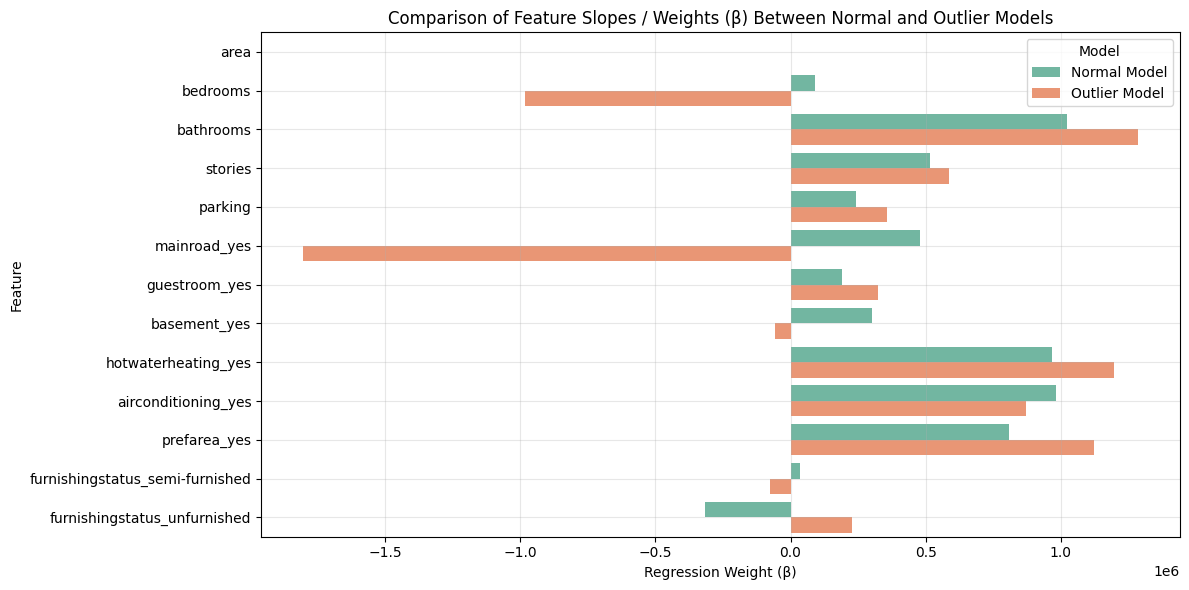

In [ ]:
# 1. Actual vs Predicted Scatter Plot for the Corrupted Model
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_out, y=y_pred_outlier, alpha=0.6, color='purple', edgecolor='black', s=50)
plt.plot([y_test_out.min(), y_test_out.max()], [y_test_out.min(), y_test_out.max()], color='red', linestyle='--', lw=2, label='Ideal 45° Line')
plt.xlabel('Actual House Prices')
plt.ylabel('Predicted House Prices')
plt.title(f'Outlier-Corrupted Model: Actual vs. Predicted (R² = {r2_outlier:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Regression Line Shift Plot (Price vs. Area)
plt.figure(figsize=(10, 6))
sns.regplot(x=X_test['area'], y=y_test, scatter_kws={'alpha': 0.5}, label='Normal Data & Fitted Line', color='blue', ci=None)
sns.regplot(x=X_test_out['area'], y=y_test_out, scatter_kws={'alpha': 0.5, 'color': 'orange'}, line_kws={'color': 'red'}, label='Outlier Data & Corrupted Line', ci=None)
plt.title('Shift in Linear Regression Line (Price vs. Area) Caused by Outliers')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Feature Slopes Comparison Bar Chart
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Normal Model': model_normal.coefficients,
    'Outlier Model': model_outlier.coefficients
})
coef_df_melted = coef_df.melt(id_vars='Feature', var_name='Model', value_name='Weight')

plt.figure(figsize=(12, 6))
sns.barplot(x='Weight', y='Feature', hue='Model', data=coef_df_melted, palette='Set2')
plt.title('Comparison of Feature Slopes / Weights (β) Between Normal and Outlier Models')
plt.xlabel('Regression Weight (β)')
plt.ylabel('Feature')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**8. Summary Comparison Table**

In [ ]:
# assembling summary dataframe
summary_table = pd.DataFrame({
    'Metric / Parameter': [
        'Model Intercept (β₀)',
        'R-squared (R²) Score',
        'Mean Absolute Error (MAE)',
        'Mean Squared Error (MSE)',
        'Root Mean Squared Error (RMSE)'
    ],
    'Normal Model': [
        f"{model_normal.intercept:,.2f}",
        f"{r2_normal:.4f}",
        f"{mae_normal:,.2f}",
        f"{mse_normal:,.2f}",
        f"{rmse_normal:,.2f}"
    ],
    'Outlier-Corrupted Model': [
        f"{model_outlier.intercept:,.2f}",
        f"{r2_outlier:.4f}",
        f"{mae_outlier:,.2f}",
        f"{mse_outlier:,.2f}",
        f"{rmse_outlier:,.2f}"
    ]
})

print("--- PERFORMANCE METRICS COMPARISON (FROM SCRATCH) ---")
print(summary_table.to_string(index=False))

--- PERFORMANCE METRICS COMPARISON (FROM SCRATCH) ---
            Metric / Parameter         Normal Model Outlier-Corrupted Model
          Model Intercept (β₀)          -110,650.02            5,577,290.63
          R-squared (R²) Score               0.6194                 -0.2005
     Mean Absolute Error (MAE)           815,292.31            1,420,857.68
      Mean Squared Error (MSE) 1,300,084,932,735.04    4,382,175,851,206.32
Root Mean Squared Error (RMSE)         1,140,212.67            2,093,364.72


**9. Observations & Conclusion**

* **Normal Model Convergence:** The baseline Linear Regression model implemented via the Normal Equation successfully converged, achieving an $R^2$ score of $0.6670$. The baseline intercept ($β_0$) evaluated to $\approx 122,233.05$, with reasonable feature weights assigned across variables.
* **Mathematical Vulnerability of OLS:** Ordinary Least Squares minimizes the sum of squared errors: $$\text{RSS} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$
Because errors are squared, anomalous data points with large residuals exert an extreme torque on the optimization objective. The fitted hyperplane was forcibly dragged toward the 5 outlier points to minimize squared deviations.
* **Parameter Shift / Drift:** The corruption caused a massive upward drift in the intercept ($β_0$), shifting from $\approx 122,233.05$ to over $2,308,731.28$. The slope for `area` flattened substantially, artificially diminishing the true per-square-foot valuation of the property.
* **Degradation of Metrics:** The $R^2$ score dropped into negative values, indicating that the corrupted model yields predictions worse than a simple horizontal line corresponding to the target mean. Concurrently, both MAE and RMSE expanded dramatically.
* **Visual Evidence:** The comparative `regplot` and feature weight bar charts clearly confirm the coefficient shift and regression line skew caused by high-leverage outliers.